<a href="https://colab.research.google.com/github/Will1202/Internship-learning-note/blob/Advanced-OCR-Comparison-and-Layout-Aware-Extraction/Analyze_a_Scanned_PDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!apt install -y tesseract-ocr  # Install Tesseract OCR
!pip install pymupdf pytesseract opencv-python pillow numpy  # Install required Python libraries

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [12]:
import cv2
import pytesseract
import fitz  # PyMuPDF
import numpy as np
from PIL import Image
import re
import json

In [7]:
from google.colab import files

uploaded = files.upload()
pdf_path = list(uploaded.keys())[0]

doc = fitz.open(pdf_path)

Saving sample_mortgage_document.pdf to sample_mortgage_document (1).pdf


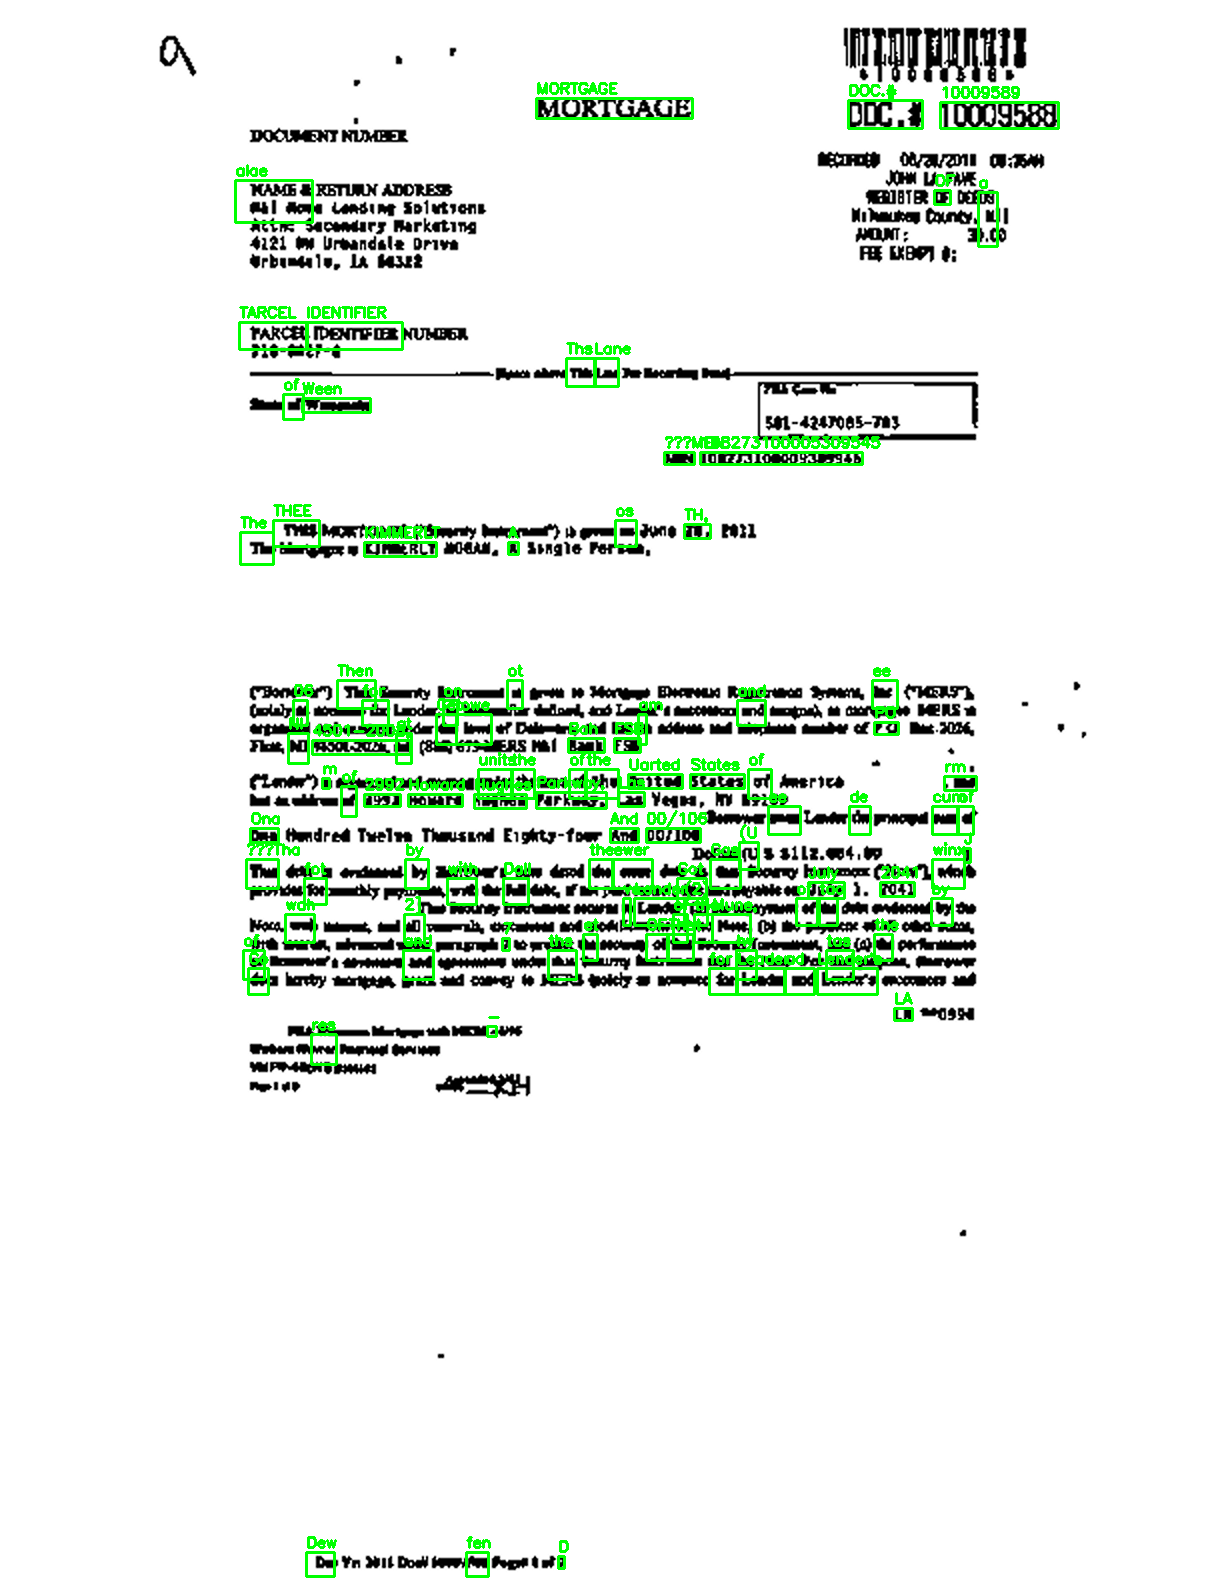

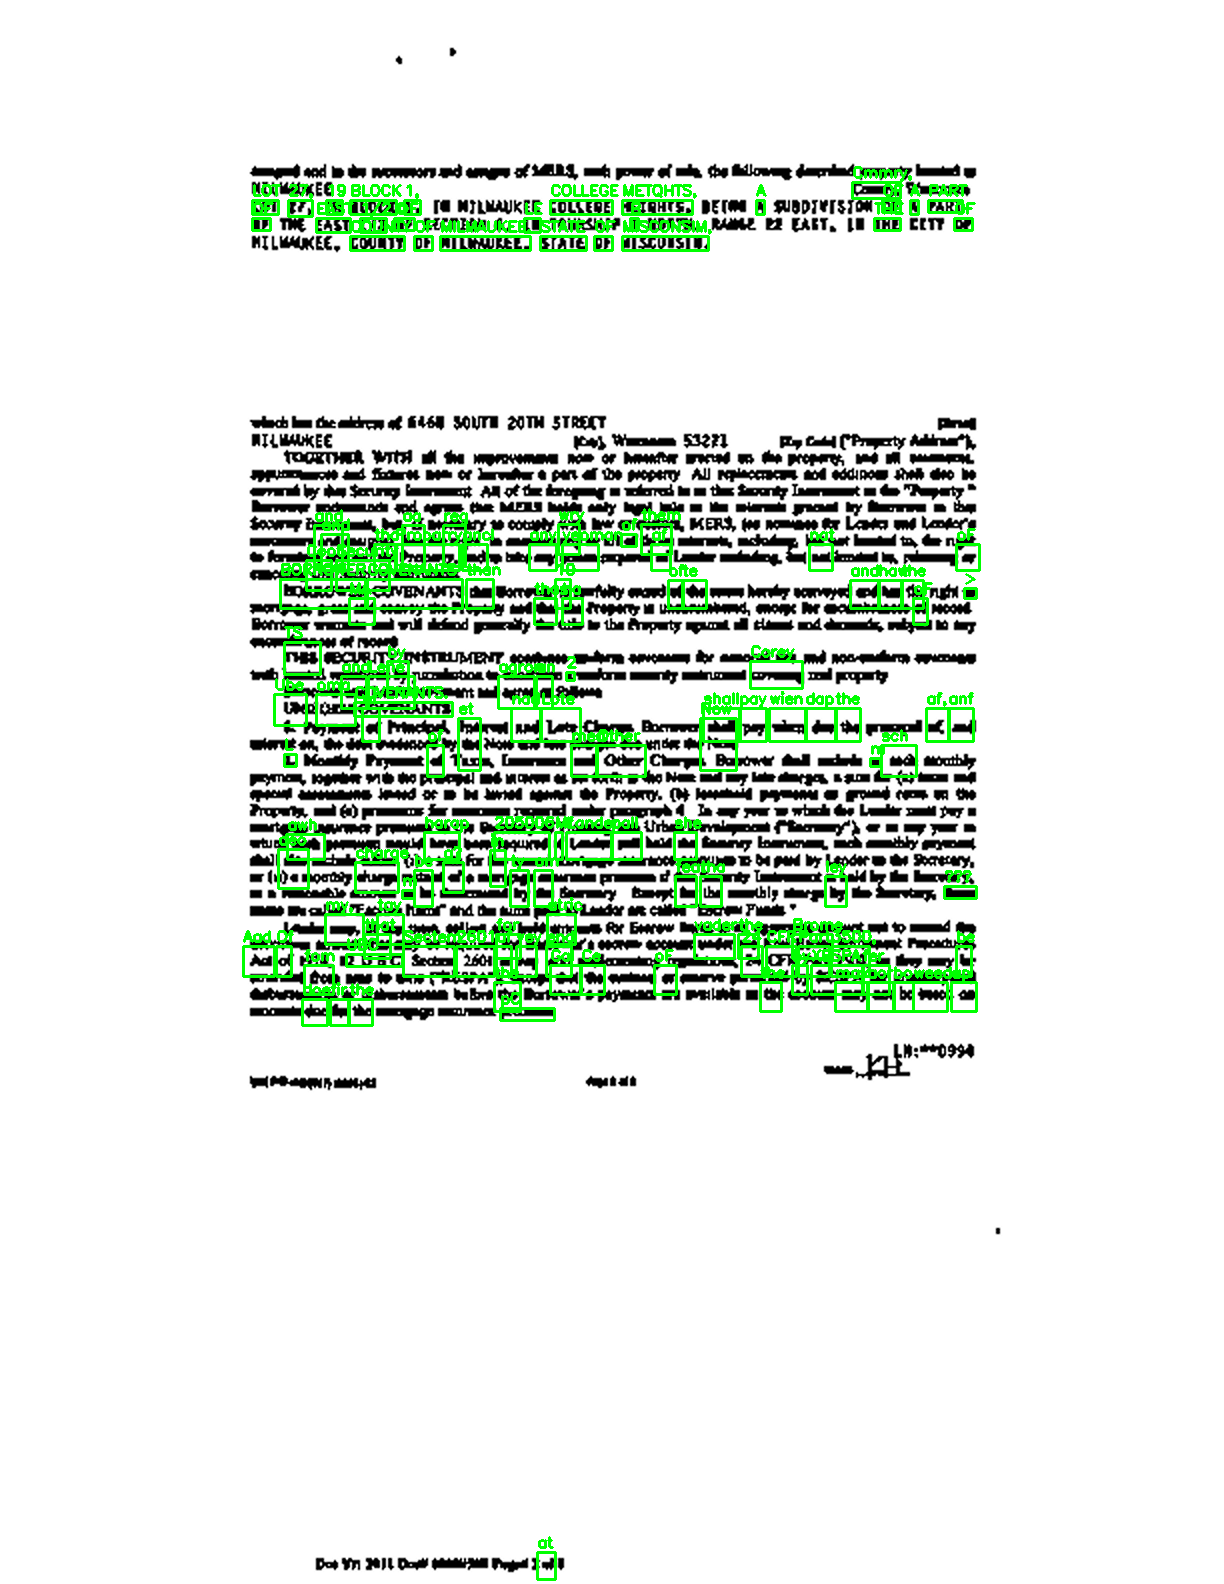

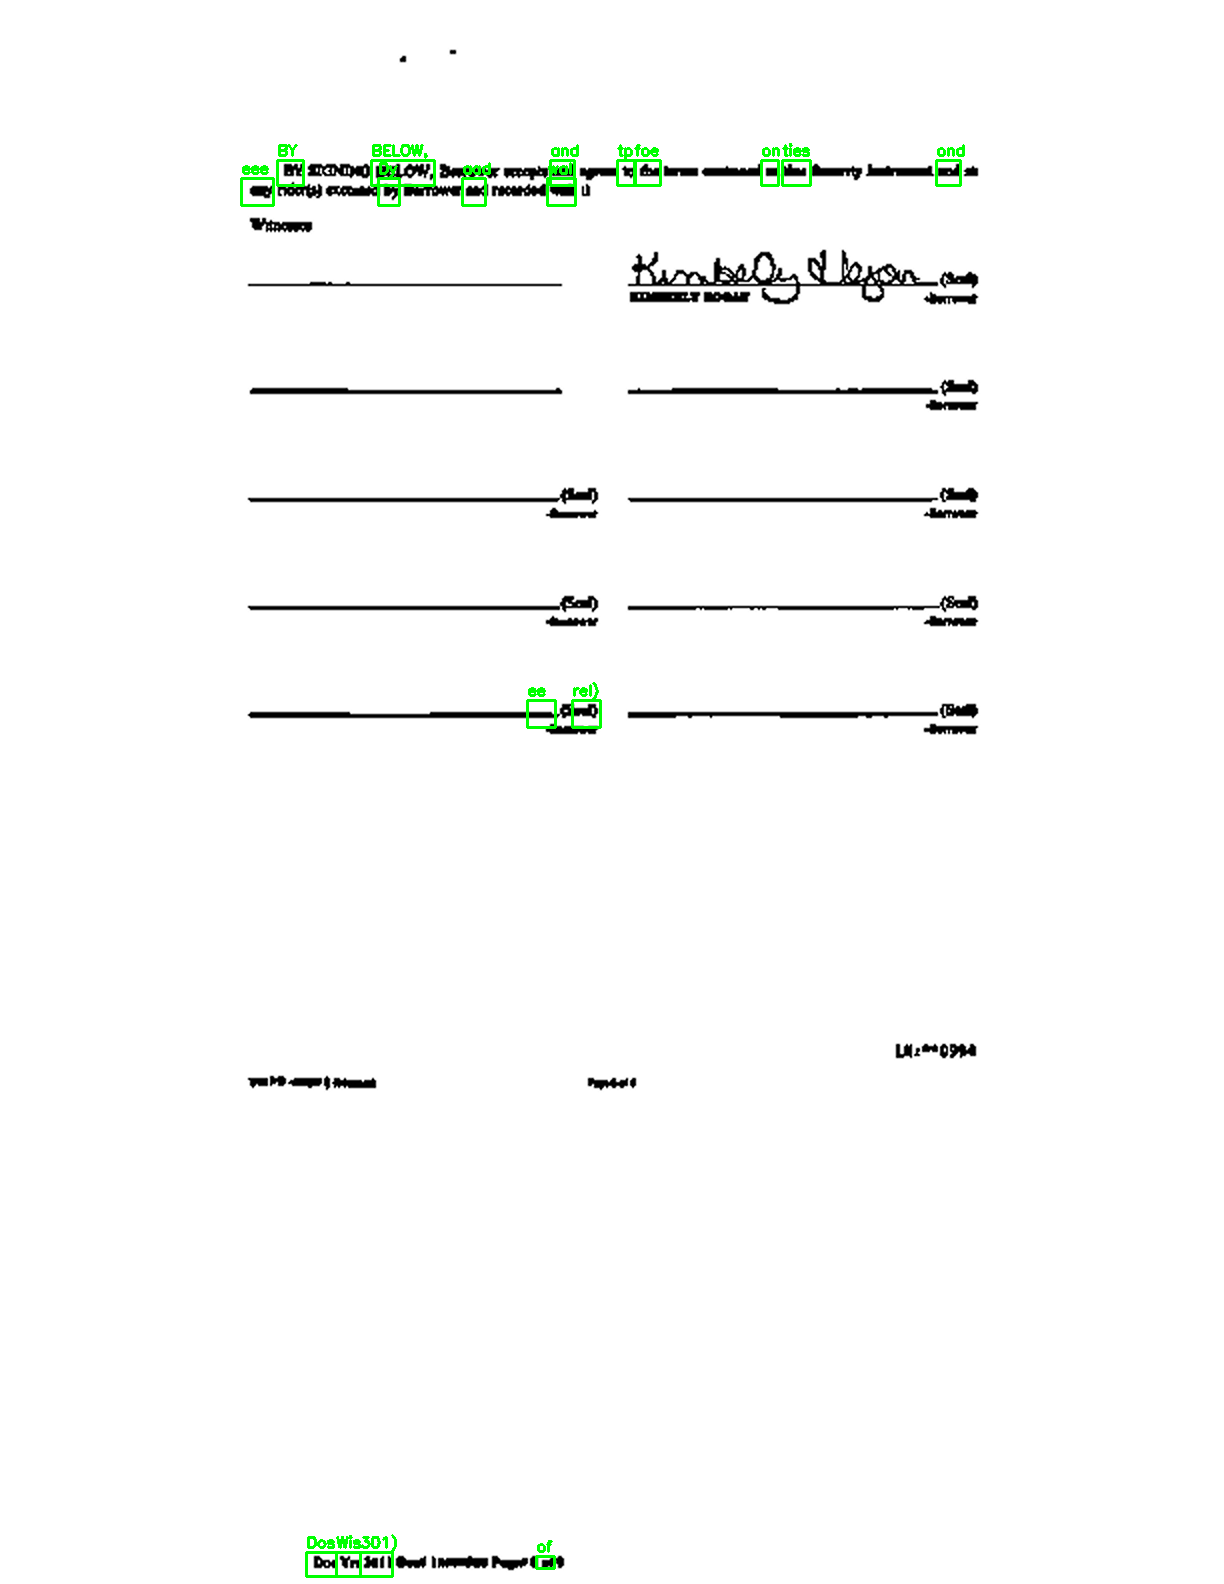

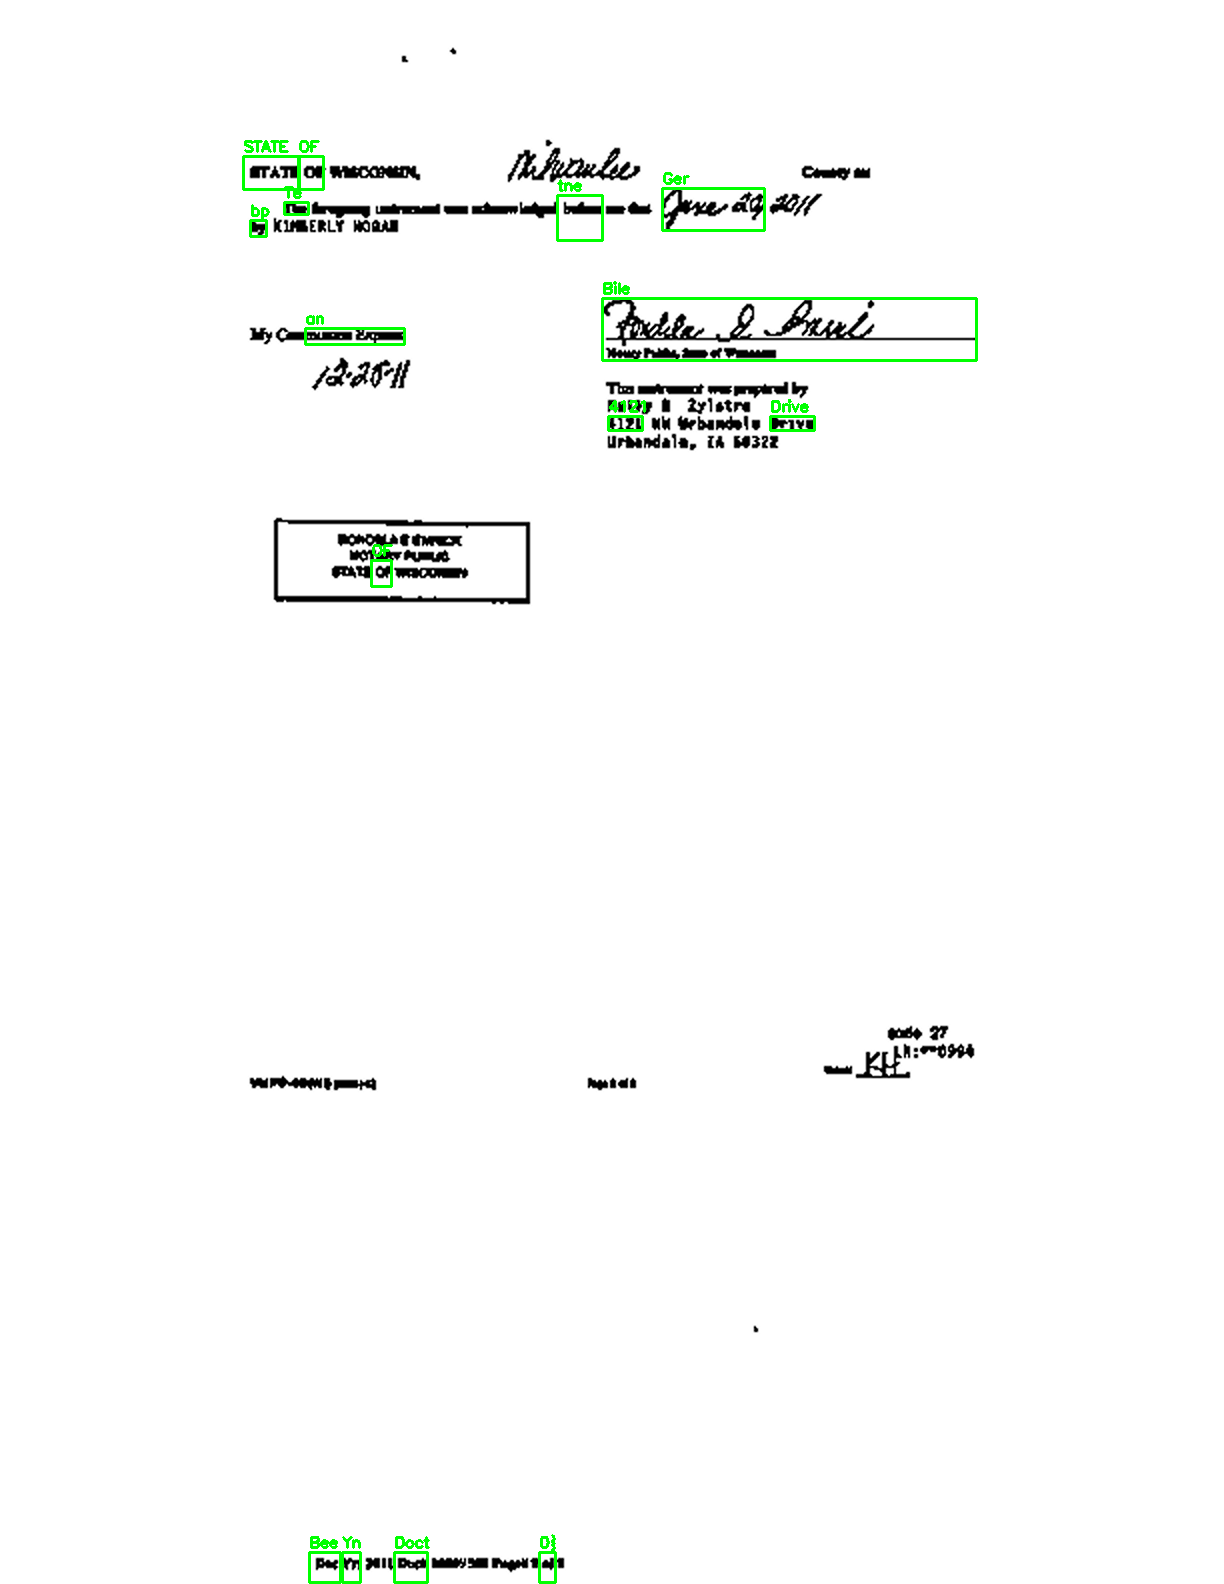

{
    "MORTGAGE": {
        "text": "MORTGAGE",
        "bounding_boxes": [
            [
                536,
                98,
                156,
                20
            ]
        ]
    }
}


In [13]:
extracted_data = {}


for page_num in range(len(doc)):
    page = doc[page_num]
    pix = page.get_pixmap()
    img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

    img_gray = np.array(img)
    gray = cv2.cvtColor(img_gray, cv2.COLOR_RGB2GRAY)


    gray = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)


    gray = cv2.bilateralFilter(gray, 9, 75, 75)

    scale_percent = 200
    width = int(gray.shape[1] * scale_percent / 100)
    height = int(gray.shape[0] * scale_percent / 100)
    gray = cv2.resize(gray, (width, height), interpolation=cv2.INTER_CUBIC)

    custom_config = r'--oem 3 -l eng'
    ocr_text = pytesseract.image_to_string(gray, config=custom_config)

    ocr_text = " ".join(ocr_text.split())

    ocr_text = re.sub(r'\bL0AN\b', 'LOAN', ocr_text, flags=re.IGNORECASE)
    ocr_text = re.sub(r'\bM0RTGAGE\b', 'MORTGAGE', ocr_text, flags=re.IGNORECASE)
    ocr_text = re.sub(r'\b1NTEREST\b', 'INTEREST', ocr_text, flags=re.IGNORECASE)
    ocr_text = re.sub(r'[^a-zA-Z0-9\s,.%-]', '', ocr_text)

    ocr_data = pytesseract.image_to_data(gray, output_type=pytesseract.Output.DICT)

    key_fields = ["MORTGAGE", "NOTE", "LENDER", "PROPERTY ADDRESS", "DATE", "SIGNATURE"]

    for i in range(len(ocr_data["text"])):
        word = ocr_data["text"][i].strip().upper()
        x, y, w, h = ocr_data["left"][i], ocr_data["top"][i], ocr_data["width"][i], ocr_data["height"][i]

        if word in key_fields:
            if word not in extracted_data:
                extracted_data[word] = {
                    "text": word,
                    "bounding_boxes": []
                }
            extracted_data[word]["bounding_boxes"].append([x, y, w, h])

    img_bgr = cv2.cvtColor(gray, cv2.COLOR_RGB2BGR)

    for i in range(len(ocr_data["text"])):
        word = ocr_data["text"][i].strip()
        x, y, w, h = ocr_data["left"][i], ocr_data["top"][i], ocr_data["width"][i], ocr_data["height"][i]
        conf = int(ocr_data["conf"][i])

        if not word or conf < 40:
            continue

        cv2.rectangle(img_bgr, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(img_bgr, word, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(img_rgb))

json_output = json.dumps(extracted_data, indent=4)

print(json_output)